In [385]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [386]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from matplotlib.widgets import RangeSlider
from ipywidgets import interact, IntSlider, SelectionSlider
import requests
import warnings
from adjustText import adjust_text
from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf, q_stat
from arch.unitroot import PhillipsPerron
import statsmodels.api as smf
from IPython.display import display, Markdown, HTML
from sklearn.decomposition import PCA
import QuantLib as ql



warnings.simplefilter("ignore", pd.errors.PerformanceWarning)
warnings.filterwarnings("ignore", category=FutureWarning, module="pandas")
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", category=FutureWarning, module="pandas")
warnings.filterwarnings("ignore", category=DeprecationWarning, module="pandas")

from pricing.pricer import PricerClass
from itertools import combinations
from calibration import Calibration
from tradescreener import tradeScreener
from swapengine import swapEngine

from plotting_utils import residuals_actualFitted, multipleResiduals, actualVsFittedCurve, \
    fittingErrorsHeatmap, threeFactorPlot, twoFactorPlot, factorsForwardsPlot, fittingErrorsHeatmap_fwd, \
    currentErrorsHeatmap_fwd

In [387]:
data = pd.read_csv("data/bankofengland/ois/bankofengland_SONIA_filtered.csv", index_col =0, parse_dates=True)
data = data.dropna()

In [388]:
sonia = pd.read_csv("data/bankofengland/sonia fixings.csv", index_col=0, parse_dates=True)
sonia.columns = ['sonia']
sonia.sort_index(inplace=True)

/var/folders/6s/ljt_tdhn2332n40p605w9dgr0000gn/T/ipykernel_89034/2464341733.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  sonia = pd.read_csv("data/bankofengland/sonia fixings.csv", index_col=0, parse_dates=True)


Unfortunately, the 0.75y datapoint is missing for a few weeks in the recent period, so we drop it.

In [389]:
bankrate =pd.read_csv("data/bankofengland/bankrate.csv")
bankrate["Date"] = pd.to_datetime(bankrate["Date"], format="%d %b %y")
bankrate.columns = ['date', 'short']
bankrate.set_index('date', inplace=True)
bankrate.index = pd.to_datetime(bankrate.index)
bankrate.sort_index(inplace=True)

In [390]:
zeroCouponYields = pd.merge(bankrate, data, left_index=True, right_index=True, how = 'inner')
zeroCouponYields.columns = ['short'] + [float(x) for x in zeroCouponYields.columns if x != 'short']
zeroCouponYields.sort_index(inplace=True)

### 1. Calibration from 2014 to 2022, on yields below 25 yrs

We fit on yields from 1 to 5 years in breaks of 6 months and on yields above 5 years in breaks of 1 year. I also tried with the whole term structure in breaks of 6 months but the fit was terrible. 

In [391]:
sampleDates = ('2014-01-01', '2022-01-01')
termStructurePath = zeroCouponYields.copy()[sampleDates[0]:sampleDates[1]]
termStructurePath.index = pd.to_datetime(termStructurePath.index)
MATURITIES = [float(x) for x in termStructurePath.columns if x != 'short' and float(x) < 5] + [x for x in range(5, 26)]

cal_2022 = Calibration(termStructurePath=termStructurePath[['short'] + MATURITIES], 
                  forwardTermStructurePath=None,
                  allForwardsPath=None,
                  useInputForwards=False,
                  fairly_priced_fwd=[2, 10],
                  fwd_deltaTau= 1,
                  maturities = MATURITIES, fairly_priced=[2, 10])

In [392]:
print('Calibrating between', termStructurePath.index[0].date(), 'and', termStructurePath.index[-1].date())
print('Using maturities from', cal_2022.maturities[0], 'to', cal_2022.maturities[-1], 'years.')

best_alpha_2022 =cal_2022.calibrateAlphaSecondStep(grid = np.arange(0.5, 3, 0.01))

best_sigma_2022 = cal_2022.calibrateSigma(alpha_r = best_alpha_2022['alpha_r'], 
                                alpha_m = best_alpha_2022['alpha_m'], 
                                alpha_l = best_alpha_2022['alpha_l'], 
                                initialGuess = [0.01092, 0.00964, 0.212])

best_mu_2022 = cal_2022.calibrateMu(alpha_r = best_alpha_2022['alpha_r'], 
                          alpha_m = best_alpha_2022['alpha_m'], 
                          alpha_l = best_alpha_2022['alpha_l'], 
                          sigma_m = best_sigma_2022['sigma_m'], 
                          sigma_l = best_sigma_2022['sigma_l'], 
                          rho = best_sigma_2022['rho'], 
                          initialGuess = 0.01, lossDecayFactor= 0.8, extraction = 'fwd')        # REMARK: Calibration here was done with 2y-fwd and 10y-fwd 1-year

Calibrating between 2016-01-04 and 2021-12-31
Using maturities from 0.0833 to 25 years.
alpha_r: 2.0000000000000013, alpha_m: 0.34649439084935024,               alpha_l: 0.0394693280836915, loss: 0.13772671473053802,              success: True, message: CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL
sigma_m: 0.03358051125683575, sigma_l: 0.06323573503048079, rho: 0.212204538224111, loss: 3.34166266338262e-07, success: True, message: CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL
mu: 2.160626091202574, loss: 356.59081784954674, success: True, message: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH


#### 1.1 Inspecting calibration fit

In [393]:
empiricalAlpha = np.vstack([x for x in cal_2022.regression()])
modelImpliedAlpha = np.vstack([[cal_2022.alphaComparison(tau = x, alpha_r = best_alpha_2022['alpha_r'], 
                                                         alpha_m = best_alpha_2022['alpha_m'], alpha_l = best_alpha_2022['alpha_l'])] for x in cal_2022.maturities])

comparisonDf_2y = pd.DataFrame({'spot maturity': cal_2022.maturities, 'empirical': empiricalAlpha[:, 0], 'model implied': modelImpliedAlpha[:, 0]}).set_index('spot maturity')
comparisonDf_10y = pd.DataFrame({'spot maturity': cal_2022.maturities, 'empirical': empiricalAlpha[:, 1], 'model implied': modelImpliedAlpha[:, 1]}).set_index('spot maturity')

Text(0.5, 0.98, 'Model implied (given best alpha) vs empirical betas from regression')

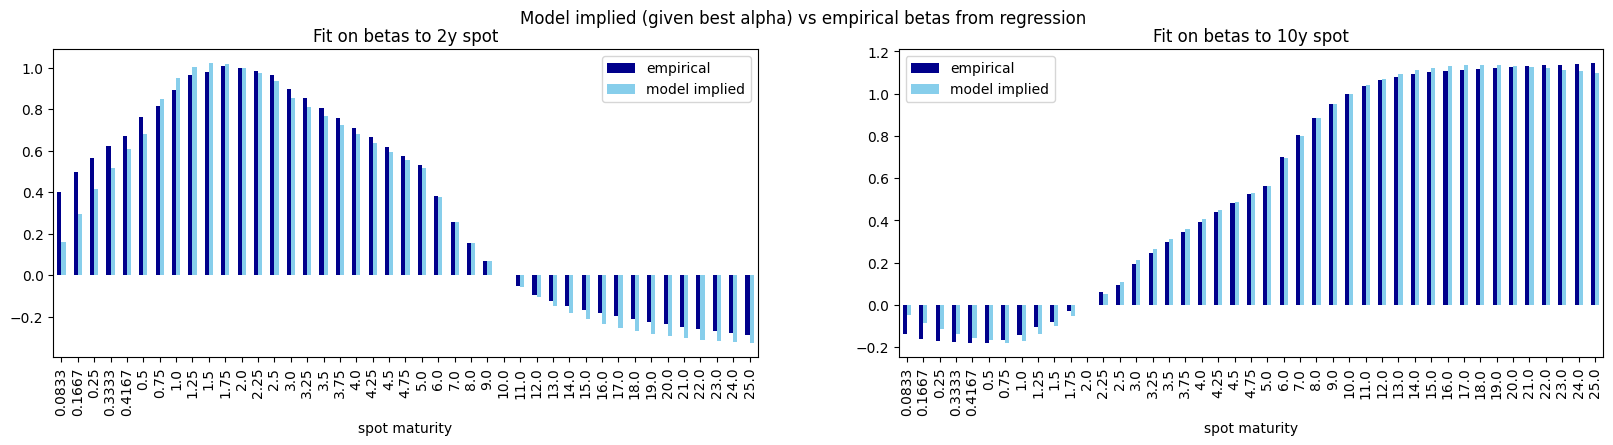

In [394]:
fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (20,4))
comparisonDf_2y.plot(kind = 'bar', ax=ax[0], title = f'Fit on betas to {int(cal_2022.fairly_priced[0])}y spot', color= ['darkblue', 'skyblue'])
comparisonDf_10y.plot(kind = 'bar', ax=ax[1], title = f'Fit on betas to {int(cal_2022.fairly_priced[1])}y spot', color= ['darkblue', 'skyblue'])
fig.suptitle("Model implied (given best alpha) vs empirical betas from regression")

In [395]:
empiricalSigma = np.array([cal_2022.empiricalVariance(tau = x, alpha_r=best_alpha_2022['alpha_r']) for x in cal_2022.maturities])
modelImpliedSigma = np.array([cal_2022.modelImpliedVariance(
    tau = x, alpha_r = best_alpha_2022['alpha_r'], alpha_m = best_alpha_2022['alpha_m'], alpha_l = best_alpha_2022['alpha_l'], 
    sigma_m = best_sigma_2022['sigma_m'], sigma_l = best_sigma_2022['sigma_l'], rho = best_sigma_2022['rho']) for x in cal_2022.maturities])

comparisonDf_sigma = pd.DataFrame({'spot maturity': cal_2022.maturities, 
                                   'empirical': empiricalSigma, 
                                   'model implied': modelImpliedSigma}).set_index('spot maturity')

<Axes: title={'center': 'Fit on variances of each yield'}, xlabel='spot maturity'>

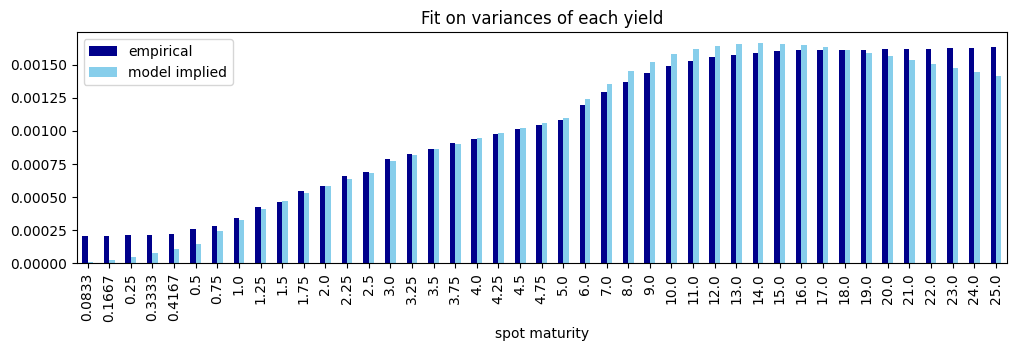

In [396]:
fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = (12,3))
comparisonDf_sigma.plot(kind = 'bar', ax=ax, title = f'Fit on variances of each yield', color= ['darkblue', 'skyblue'])

#### 1.2. Inspecting Extrapolated Factors

To get OOS extracted factors, we re-feed the calibration class with the full dataset. We've calibrated all parameters on the in-sample piece of the data, so now we can operate on the full dataset to get OOS results.

In [397]:
termStructurePath = zeroCouponYields.copy()[sampleDates[0]:None]
termStructurePath.index = pd.to_datetime(termStructurePath.index)
MATURITIES = [float(x) for x in termStructurePath.columns if x != 'short' and float(x) < 5] + [x for x in range(5, 25)]

cal_2022 = Calibration(termStructurePath=termStructurePath[['short'] + MATURITIES], 
                  forwardTermStructurePath=None,
                  allForwardsPath=None,
                  useInputForwards=False,
                  fairly_priced_fwd=[2, 10],
                  fwd_deltaTau= 1,
                  maturities = MATURITIES, fairly_priced=[2, 10])

In [398]:
lf_full_2022 = cal_2022.extractLatentFactors_fwd(alpha_r = best_alpha_2022['alpha_r'], alpha_m = best_alpha_2022['alpha_m'], alpha_l = best_alpha_2022['alpha_l'], 
                         sigma_m = best_sigma_2022['sigma_m'], sigma_l = best_sigma_2022['sigma_l'], rho = best_sigma_2022['rho'], mu = best_mu_2022['mu'])

estFactorsDf_full_2022 = pd.DataFrame(lf_full_2022, columns = ['medium', 'long'], index = zeroCouponYields[sampleDates[0]:None].index)
estFactorsDf_full_2022['short'] = termStructurePath['short']
estFactorsDf_full_2022 = estFactorsDf_full_2022[['short', 'medium', 'long']]
estFactorsDf_full_2022.iloc[-1]

short     3.750000
medium    2.065572
long      6.249720
Name: 2026-03-31 00:00:00, dtype: float64

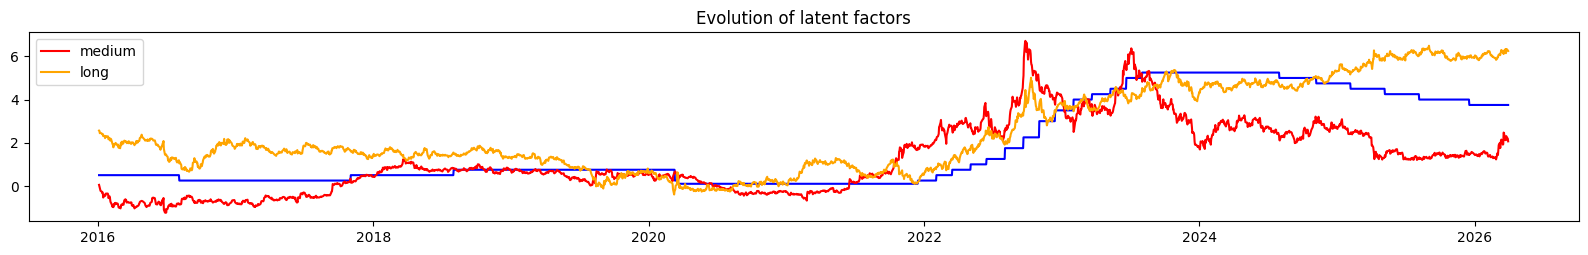

In [399]:
threeFactorPlot(estFactorsDf_full=estFactorsDf_full_2022)

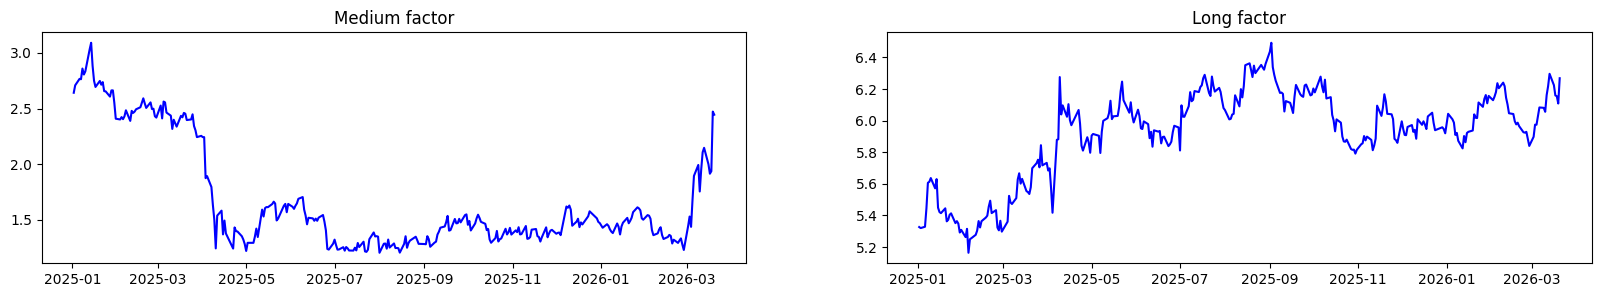

In [400]:
limits = ('2025-01-01', '2026-03-20')
twoFactorPlot(estFactorsDf_full=estFactorsDf_full_2022, limits = limits)

In [401]:
calParams_2022 = dict(alpha_r = best_alpha_2022['alpha_r'], alpha_m = best_alpha_2022['alpha_m'], alpha_l = best_alpha_2022['alpha_l'],
                  sigma_m = best_sigma_2022['sigma_m'], sigma_l = best_sigma_2022['sigma_l'], rho = best_sigma_2022['rho'], mu = best_mu_2022['mu'])

fittedPricer_2022 = PricerClass(**calParams_2022)
fittedTs_full_2022 = [fittedPricer_2022.termStructure(maturities = MATURITIES, factors = np.array(estFactorsDf_full_2022.iloc[i].values)) for i in range(len(lf_full_2022))]
fittedTs_full_df_2022 = pd.DataFrame(fittedTs_full_2022, columns = MATURITIES, index = pd.to_datetime(estFactorsDf_full_2022.index))
fittedTs_full_df_2022.index = pd.to_datetime(fittedTs_full_df_2022.index)
fittedTs_full_df_2022 - termStructurePath[[col for col in termStructurePath.columns if col in fittedTs_full_df_2022.columns]]

,0.0833,0.1667,0.2500,0.3333,0.4167,0.5000,0.7500,1.0000,1.2500,1.5000,...,15.0000,16.0000,17.0000,18.0000,19.0000,20.0000,21.0000,22.0000,23.0000,24.0000
date,,,,,,,,,,,,,,,,,,,,,
2016-01-04,0.003468,-0.025323,-0.048351,-0.067069,-0.082595,-0.104469,-0.124255,-0.143103,-0.173010,-0.161605,...,0.038489,0.031024,0.025014,0.020486,0.017325,0.015312,0.014143,0.013510,0.013151,0.012851
2016-01-05,-0.002560,-0.036086,-0.062430,-0.083798,-0.101331,-0.122476,-0.144160,-0.160916,-0.187010,-0.174769,...,0.031984,0.025017,0.019515,0.015493,0.012830,0.011297,0.010584,0.010375,0.010410,0.010475
2016-01-06,-0.005315,-0.042099,-0.071463,-0.094813,-0.113517,-0.133644,-0.158820,-0.175724,-0.197724,-0.185233,...,0.029843,0.022269,0.016102,0.011357,0.007918,0.005565,0.003998,0.002917,0.002080,0.001296
2016-01-07,-0.016042,-0.058816,-0.093467,-0.121644,-0.144459,-0.166551,-0.197559,-0.215110,-0.235226,-0.222409,...,0.025668,0.017880,0.011317,0.006045,0.001984,-0.001054,-0.003342,-0.005166,-0.006759,-0.008316
2016-01-08,-0.019175,-0.066302,-0.105066,-0.136490,-0.161610,-0.184076,-0.218172,-0.234791,-0.252182,-0.239081,...,0.026499,0.019210,0.013131,0.008303,0.004638,0.001946,-0.000037,-0.001586,-0.002927,-0.004251
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-25,-0.115897,-0.273225,-0.420698,-0.552424,-0.667892,-0.807382,-0.972841,-1.080437,-1.131519,-1.116353,...,0.006534,-0.042587,-0.092493,-0.142180,-0.190889,-0.238061,-0.283297,-0.326329,-0.367008,-0.405277
2026-03-26,-0.098927,-0.245073,-0.385739,-0.514251,-0.629356,-0.781192,-0.945290,-1.058971,-1.113521,-1.093745,...,0.021702,-0.029228,-0.081002,-0.132685,-0.183543,-0.233006,-0.280638,-0.326124,-0.369262,-0.409946
2026-03-27,-0.102117,-0.243835,-0.381032,-0.506817,-0.619541,-0.764820,-0.926677,-1.035669,-1.087029,-1.067174,...,0.021405,-0.028451,-0.078897,-0.129061,-0.178299,-0.226144,-0.272274,-0.316464,-0.358565,-0.398482


In [402]:
fittingErrors_2022 = fittedTs_full_df_2022 - termStructurePath[[col for col in termStructurePath.columns if col in fittedTs_full_df_2022.columns]].dropna(axis= 1)
fittingErrors_byYear_2022 = (fittingErrors_2022.groupby(fittingErrors_2022.index.year).apply(lambda x: np.sqrt((x**2).mean()).round(5))).T * 100

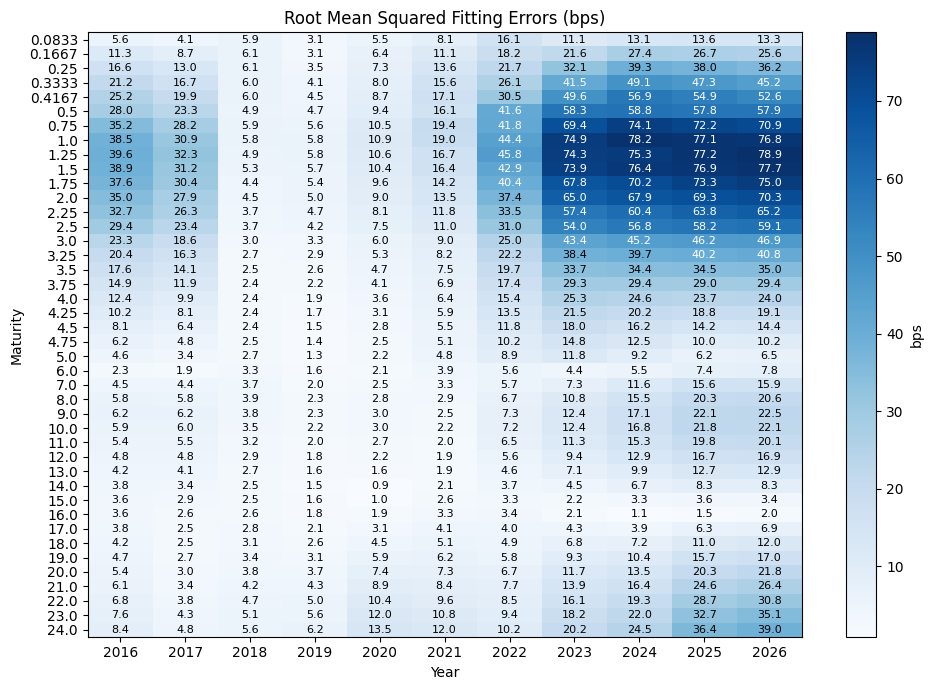

In [403]:
fittingErrorsHeatmap(fittingErrors_byYear=fittingErrors_byYear_2022, figsize = (10, 7))

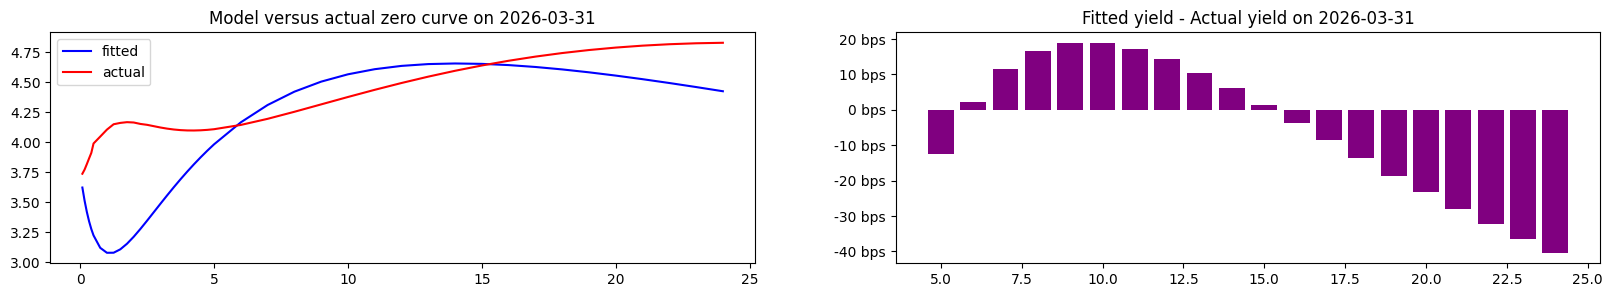

In [404]:
actualVsFittedCurve(targetDate='2026-03-31',
                    fittedTs_full_df=fittedTs_full_df_2022[[x for x in MATURITIES if x in fittedTs_full_df_2022.columns]],
                    termStructurePath=termStructurePath[[x for x in MATURITIES if x in fittedTs_full_df_2022.columns] + ['short']],
                    tenorsAbove=4)

### 2. Calibration from 2016 to 2024, on yields up to 35 yrs

In [405]:
sampleDates = ('2016-01-01', '2024-01-01')
termStructurePath = zeroCouponYields.copy()[sampleDates[0]:sampleDates[1]]
termStructurePath.index = pd.to_datetime(termStructurePath.index)
MATURITIES = [float(x) for x in termStructurePath.columns if x != 'short' and float(x) < 5] + [x for x in range(5, 26)]

print('Using maturities from', MATURITIES[0], 'to', MATURITIES[-1], 'years.')

cal_2024 = Calibration(termStructurePath=termStructurePath[['short'] + MATURITIES], 
                  forwardTermStructurePath=None,
                  allForwardsPath=None,
                  useInputForwards=False,
                  fairly_priced_fwd=[2, 10],
                  fwd_deltaTau= 1,
                  maturities = MATURITIES, fairly_priced=[2, 10])

Using maturities from 0.0833 to 25 years.


In [406]:
print('Calibrating between', termStructurePath.index[0].date(), 'and', termStructurePath.index[-1].date())
print('Using maturities from', cal_2024.maturities[0], 'to', cal_2024.maturities[-1], 'years.')
best_alpha_2024 =cal_2024.calibrateAlphaSecondStep(grid = np.arange(0.5, 3, 0.01))

best_sigma_2024 = cal_2024.calibrateSigma(alpha_r = best_alpha_2024['alpha_r'], 
                                alpha_m = best_alpha_2024['alpha_m'], 
                                alpha_l = best_alpha_2024['alpha_l'], 
                                initialGuess = [0.01092, 0.00964, 0.212])

best_mu_2024 = cal_2024.calibrateMu(alpha_r = best_alpha_2024['alpha_r'], 
                          alpha_m = best_alpha_2024['alpha_m'], 
                          alpha_l = best_alpha_2024['alpha_l'], 
                          sigma_m = best_sigma_2024['sigma_m'], 
                          sigma_l = best_sigma_2024['sigma_l'], 
                          rho = best_sigma_2024['rho'], 
                          initialGuess = 0.01, lossDecayFactor= 0.8, extraction = 'fwd')        # REMARK: Calibration here was done with 2y-fwd and 10y-fwd 1-year

Calibrating between 2016-01-04 and 2023-12-29
Using maturities from 0.0833 to 25 years.
alpha_r: 2.4800000000000018, alpha_m: 0.4086779948506381,               alpha_l: 0.030639243529446577, loss: 0.20962433288274296,              success: True, message: CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL
sigma_m: 0.07968001834043399, sigma_l: 0.07595348011320834, rho: 0.21266892857040617, loss: 4.1559827597269715e-06, success: True, message: CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL
mu: 4.258353588392869, loss: 1553.7207291708455, success: True, message: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH


In [407]:
termStructurePath = zeroCouponYields.copy()[sampleDates[0]:None]
termStructurePath.index = pd.to_datetime(termStructurePath.index)

cal_2024 = Calibration(termStructurePath=termStructurePath[['short'] + MATURITIES], 
                  forwardTermStructurePath=None,
                  allForwardsPath=None,
                  useInputForwards=False,
                  fairly_priced_fwd=[2, 10],
                  fwd_deltaTau= 1,
                  maturities = MATURITIES, fairly_priced=[2, 10])

In [408]:
lf_full_2024 = cal_2024.extractLatentFactors_fwd(alpha_r = best_alpha_2024['alpha_r'], alpha_m = best_alpha_2024['alpha_m'], alpha_l = best_alpha_2024['alpha_l'], 
                         sigma_m = best_sigma_2024['sigma_m'], sigma_l = best_sigma_2024['sigma_l'], rho = best_sigma_2024['rho'], mu = best_mu_2024['mu'])

estFactorsDf_full_2024 = pd.DataFrame(lf_full_2024, columns = ['medium', 'long'], index = termStructurePath.index)
estFactorsDf_full_2024['short'] = termStructurePath['short']
estFactorsDf_full_2024 = estFactorsDf_full_2024[['short', 'medium', 'long']]
estFactorsDf_full_2024.iloc[-1]

estFactorsDf_full_2024['2y1y'] = (3 * zeroCouponYields[3] - 1 * zeroCouponYields[1])/2
estFactorsDf_full_2024['10y1y'] = (11 * zeroCouponYields[11] - 10 * zeroCouponYields[10])/1

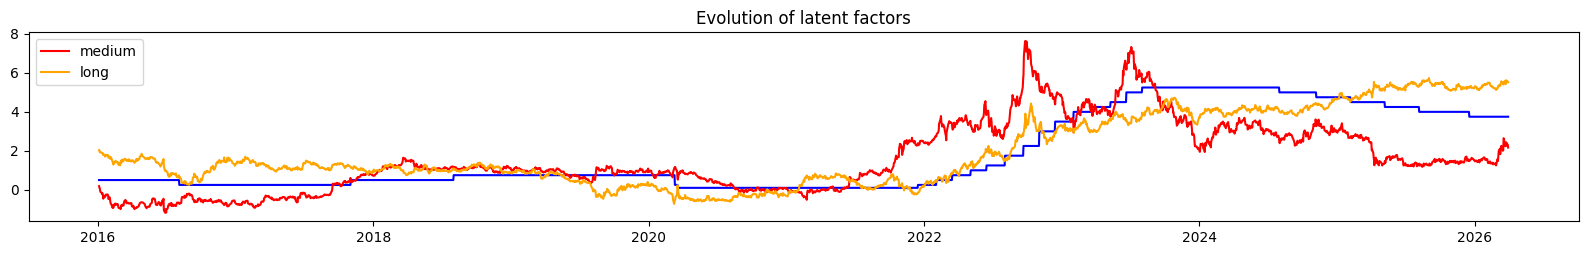

In [409]:
threeFactorPlot(estFactorsDf_full=estFactorsDf_full_2024)

What happened to the factors during the fiscal episodes of 2022?

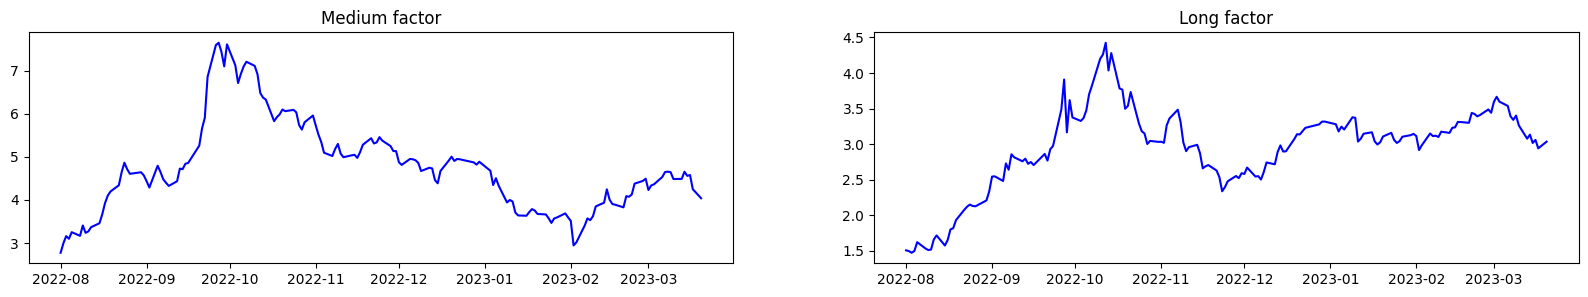

In [410]:
limits = ('2022-08-01', '2023-03-20')
twoFactorPlot(estFactorsDf_full=estFactorsDf_full_2024, limits = limits)

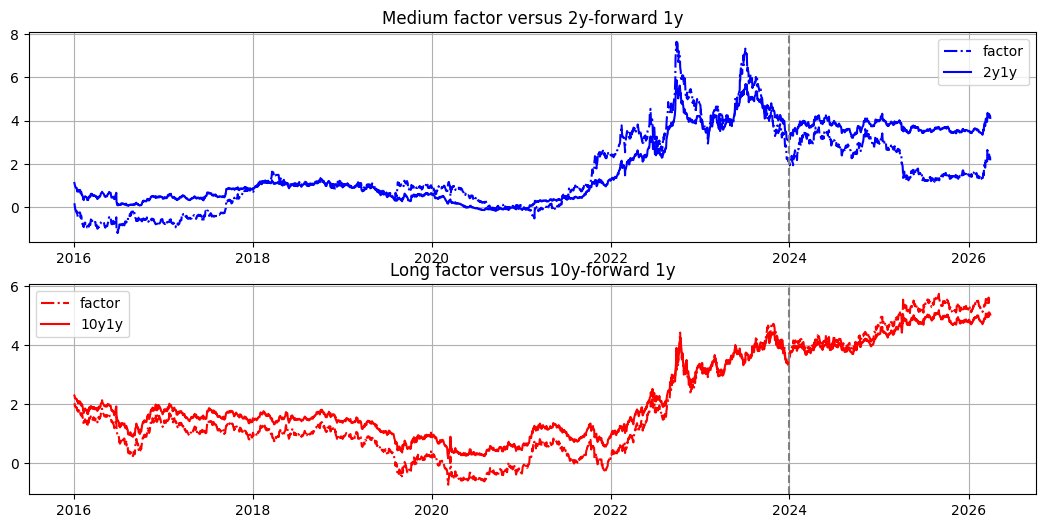

In [411]:
factorsForwardsPlot(estFactorsDf_full=estFactorsDf_full_2024, sampleDates=sampleDates, figsize=(13,6))

In [412]:
calParams_2024 = dict(alpha_r = best_alpha_2024['alpha_r'], alpha_m = best_alpha_2024['alpha_m'], alpha_l = best_alpha_2024['alpha_l'],
                  sigma_m = best_sigma_2024['sigma_m'], sigma_l = best_sigma_2024['sigma_l'], rho = best_sigma_2024['rho'], mu = best_mu_2024['mu'])

fittedPricer_2024 = PricerClass(**calParams_2024)
fittedTs_full_2024 = [fittedPricer_2024.termStructure(maturities = MATURITIES, factors = np.array(estFactorsDf_full_2024.iloc[i].values)) for i in range(len(lf_full_2024))]
fittedTs_full_df_2024 = pd.DataFrame(fittedTs_full_2024, columns = MATURITIES, index = pd.to_datetime(termStructurePath.index))
fittedTs_full_df_2024.index = pd.to_datetime(fittedTs_full_df_2024.index)

fittingErrors_2024 = (fittedTs_full_df_2024 - termStructurePath).dropna(axis= 1)
fittingErrors_byYear_2024 = (fittingErrors_2024.groupby(fittingErrors_2024.index.year).apply(lambda x: np.sqrt((x**2).mean()).round(5))).T * 100

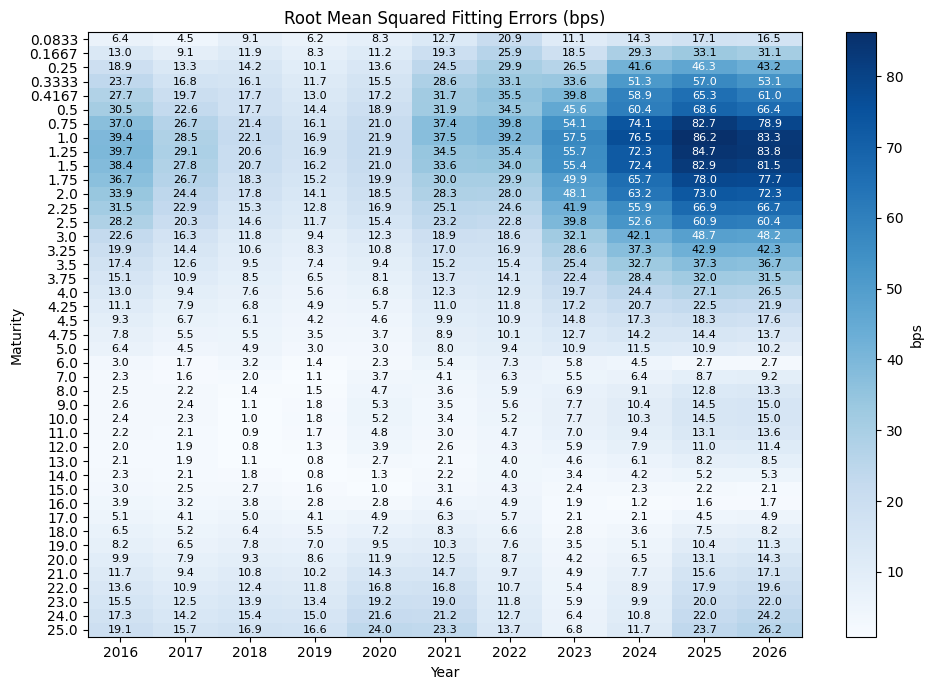

In [413]:
fittingErrorsHeatmap(fittingErrors_byYear=fittingErrors_byYear_2024, figsize = (10, 7))

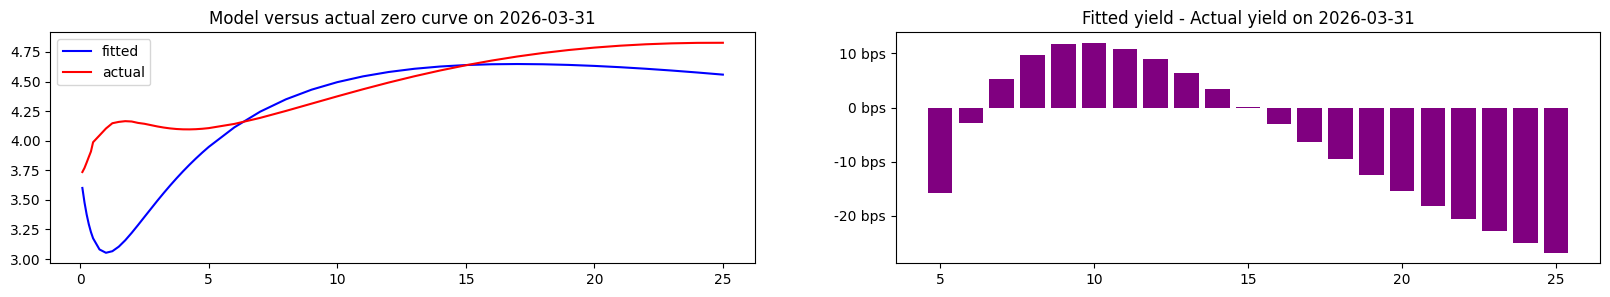

In [414]:
actualVsFittedCurve(targetDate='2026-03-31',
                    fittedTs_full_df=fittedTs_full_df_2024[[x for x in MATURITIES if x in fittedTs_full_df_2024.columns]],
                    termStructurePath=termStructurePath[[x for x in MATURITIES if x in fittedTs_full_df_2024.columns] + ['short']],
                    tenorsAbove=4)

### 3. From par to zero curves

In [415]:
def make_zero_curve_from_row(row, eval_date, calendar=ql.UnitedKingdom()):
    row = row.copy()

    short_rate = float(row.pop('short')) / 100.0
    maturities = [float(c) for c in row.index]
    zero_rates = [float(x) / 100.0 for x in row.values]

    dates = [eval_date]
    rates = [short_rate]

    for t, r in zip(maturities, zero_rates):
        d = eval_date + ql.Period(int(round(t * 12)), ql.Months)
        dates.append(d)
        rates.append(r)

    curve = ql.ZeroCurve(
        dates,
        rates,
        ql.Actual365Fixed(),
        calendar,
        ql.Linear(),
        ql.Continuous,
        ql.Annual
    )
    return ql.YieldTermStructureHandle(curve)


def par_ois_curve_from_zero_df(zero_df, swap_maturities=None):
    calendar = ql.UnitedKingdom()
    day_count = ql.Actual365Fixed()

    if swap_maturities is None:
        swap_maturities = [float(c) for c in zero_df.columns if c != 'short']

    out = []

    for dt, row in zero_df.iterrows():
        eval_date = ql.Date(dt.day, dt.month, dt.year)
        ql.Settings.instance().evaluationDate = eval_date

        curve_handle = make_zero_curve_from_row(row, eval_date, calendar)
        curve_handle.enableExtrapolation()
        engine = ql.DiscountingSwapEngine(curve_handle)
        ois_index = ql.Sonia(curve_handle)

        par_rates = {}
        for mat in swap_maturities:
            tenor = ql.Period(int(round(mat * 12)), ql.Months)
            swap = ql.MakeOIS(
                tenor,
                ois_index,
                fixedRate=0.0,
                settlementDays=0,
                paymentLag=0,
                fixedLegDayCount=day_count,
                telescopicValueDates=True,
            )
            swap.setPricingEngine(engine)
            par_rates[mat] = 100.0 * swap.fairRate()

        out.append(pd.Series(par_rates, name=dt))

    return pd.DataFrame(out)

In [416]:
def _parse_trade_name(name):
    parts = str(name).split('s')
    nums = [float(x) for x in parts if x != '']
    if len(nums) == 1:
        return ('outright', nums)
    if len(nums) == 2:
        return ('slope', nums)
    if len(nums) == 3:
        return ('fly', nums)
    raise ValueError(f"Cannot parse trade name: {name}")

In [417]:
par_obs = par_ois_curve_from_zero_df(termStructurePath[[x for x in MATURITIES if x in fittedTs_full_df_2024.columns] + ['short']])
par_fit = par_ois_curve_from_zero_df(pd.concat([termStructurePath['short'], fittedTs_full_df_2024], axis=1))
par_resid = par_obs - par_fit

### 4. Models backtest (2016-2024 calibration, 1y-30y)

In [418]:
engine = swapEngine(sonia)

screen = tradeScreener(modelData = par_fit,
                       actualData = par_obs,
                       maturitySet = [x for x in cal_2024.maturities if int(x) > 0],
                       modelData_fwd= fittedTs_full_df_2024,         # PLEASE FEED FORWARDS IF YOU WANT TO SCREEN FOR FORWARDS
                       actualData_fwd= fittedTs_full_df_2024,
                       maturitySet_fwd=None,
                       swapEngine = engine,
                       swap_zeroCurve = zeroCouponYields,
                       swap_parCurve = par_obs)

In [424]:
allSlopesBacktest = screen.allSlopesBacktest_swaps(**backtestParams)

In [461]:
above4y = allSlopesBacktest.loc[
    allSlopesBacktest['slope'].apply(
        lambda x: min(_parse_trade_name(x)[1]) >= 4.5)]

In [475]:
above4y.sort_values('tot pnl')

,slope,hitrate,skew,avg days,median days,n_trades,stop,avg pnl,tot pnl
491,8s23s,0.600000,0.236571,2.600000,1.0,10,0.600000,-0.730566,-7.305660
506,9s22s,0.555556,0.274974,3.111111,4.0,9,0.555556,-0.780007,-7.020061
505,9s21s,0.555556,0.276666,3.111111,4.0,9,0.555556,-0.750513,-6.754620
504,9s20s,0.500000,0.301892,3.000000,2.5,8,0.500000,-0.748708,-5.989667
508,9s24s,0.636364,0.272750,3.090909,4.0,11,0.636364,-0.539731,-5.937036
...,...,...,...,...,...,...,...,...,...
396,4.5s23s,0.777778,0.626991,2.555556,2.0,9,0.777778,1.112891,10.016022
414,4.75s20s,0.857143,0.661960,2.571429,2.0,7,0.857143,1.466423,10.264964
398,4.5s25s,0.777778,0.634421,2.444444,2.0,9,0.777778,1.162978,10.466804
397,4.5s24s,0.777778,0.640085,2.444444,2.0,9,0.777778,1.168724,10.518515


In [462]:
backtestParams = dict(
    startDt='2024-01-01', 
    endDt=None,
    shortW = 5, 
    longW = 40, 
    standardW=14,
    numberSigma = 2,
    stopLossSigma = 2.5
)

  entry_date  exit_date   side  entry_actual  exit_actual  entry_misp  exit_misp  entry_signal  exit_signal   entry_z    exit_z  entry_npv  exit_mtm       pnl  last_daily_pnl   stop       reason  days    hit
0 2024-05-09 2024-05-10  SHORT     -0.083941    -0.107228   -0.127619  -0.120647      0.009157     0.003541 -2.156510 -1.671293   0.220434  2.528638  2.308204        2.308204   True    stop_loss     1   True
1 2024-08-01 2024-08-05  SHORT      0.111253     0.079649   -0.148198  -0.109370      0.001130     0.001636 -2.205737  1.880080   0.186336  3.621617  3.435281        4.602785   True    stop_loss     4   True
2 2024-12-16 2024-12-17   LONG      0.143543     0.094504   -0.000107   0.001476     -0.023164    -0.017090  2.400162  2.529066  -0.129520 -4.859972 -4.730452       -4.730452  False  take_profit     1  False
3 2025-01-31 2025-02-05  SHORT      0.298405     0.285542   -0.029276  -0.010512      0.007893    -0.003321 -2.536872 -1.104534   0.101594  1.791382  1.689788        3.

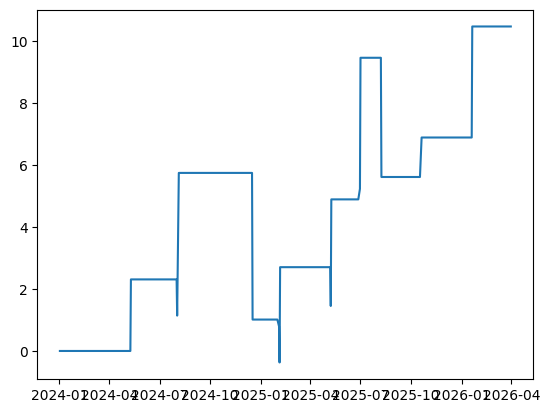

In [478]:
targetSlope = '4.5s25s'
slopeDict = screen.buildSlopes()
bt = screen.singleItemPerformance_swaps(
    modelSeries = slopeDict['model'][targetSlope],
    actualSeries= slopeDict['actual'][targetSlope],
    **backtestParams
)

print(bt.to_string())

timeSeriesPnl = screen.singleItem_dailyPnl_swaps(
    modelSeries = slopeDict['model'][targetSlope],
    actualSeries = slopeDict['actual'][targetSlope],
    **backtestParams
)

plt.plot(timeSeriesPnl.cumsum())

#### 3.1. Example of a trade mtm with the engine

In [ ]:
def _ql_date(ts):
    ts = pd.Timestamp(ts)
    return ql.Date(ts.day, ts.month, ts.year)

In [ ]:
date = '2024-03-01'
valDate = '2024-03-20'
out = engine._build_trade_book(trade_name = '10s15s20s',
                         side = 'LONG',
                         entry_ts = pd.to_datetime(date),
                         zero_curve_row = termStructurePath.loc[pd.to_datetime(date)],
                         par_curve_row = par_obs.loc[pd.to_datetime(date)])

engine._mark_trade_book(trade_book = out, 
                        val_ts = pd.to_datetime(valDate),
                        zero_curve_row = termStructurePath.loc[pd.to_datetime(valDate)],
                        )

0.32836943801561347

In [ ]:
entry_curve = engine.make_zero_curve_from_row(
    termStructurePath.loc[date],
    _ql_date(date)
)

val_curve = engine.make_zero_curve_from_row(
    termStructurePath.loc[valDate],
    _ql_date(valDate)
)

rows = []
for leg in out:
    entry_dv01 = engine._dv01(
        eval_ts= date,
        maturity_years=leg['maturity'],
        curve_handle=entry_curve,
        notional=leg['notional']
    )
    
    val_npv = engine._reprice_exact_ois_swap(
        trade_leg=leg,
        val_ts=valDate,
        curve_handle=val_curve
    )
    
    rows.append({
        'maturity': leg['maturity'],
        'notional': leg['notional'],
        'entry_dv01': entry_dv01,
        'entry_par_rate': leg['fixed_rate'],
        'val_npv': val_npv
    })

recap = pd.DataFrame(rows)
recap

,maturity,notional,entry_dv01,entry_par_rate,val_npv
0,10.0,1177.456472,1.0,3.850140,-5.600799
1,15.0,1716.429870,2.0,3.884254,10.926171
2,20.0,701.304838,1.0,3.894257,-4.997003


In [ ]:
out

[{'swap': <QuantLib.QuantLib.OvernightIndexedSwap; proxy of <Swig Object of type 'ext::shared_ptr< OvernightIndexedSwap > *' at 0x17d680870> >,
  'type': 1,
  'notional': 1177.456472131607,
  'fixed_rate': 3.8501400676840922,
  'effective_date': Date(1,3,2024),
  'maturity_date': Date(1,3,2034),
  'fixed_schedule': <QuantLib.QuantLib.Schedule; proxy of <Swig Object of type 'Schedule *' at 0x3068bc390> >,
  'entry_npv': -0.005528371922025599,
  'maturity': 10.0},
 {'swap': <QuantLib.QuantLib.OvernightIndexedSwap; proxy of <Swig Object of type 'ext::shared_ptr< OvernightIndexedSwap > *' at 0x3011c1410> >,
  'type': -1,
  'notional': 1716.4298696142412,
  'fixed_rate': 3.8842535117633123,
  'effective_date': Date(1,3,2024),
  'maturity_date': Date(1,3,2039),
  'fixed_schedule': <QuantLib.QuantLib.Schedule; proxy of <Swig Object of type 'Schedule *' at 0x3011c2f10> >,
  'entry_npv': 0.008060531784053637,
  'maturity': 15.0},
 {'swap': <QuantLib.QuantLib.OvernightIndexedSwap; proxy of <Swig

In [ ]:
par_obs.loc[pd.to_datetime(date)].loc[[10, 15, 20]]

10.0    3.850140
15.0    3.884254
20.0    3.894257
Name: 2024-03-01 00:00:00, dtype: float64

In [ ]:
2 * 3.884254 - 3.850140 - 3.894257

0.02411099999999955

In [ ]:
par_obs.loc[pd.to_datetime(valDate)].loc[[10, 15, 20]]

10.0    3.782363
15.0    3.821377
20.0    3.837203
Name: 2024-03-20 00:00:00, dtype: float64

In [ ]:
2 * 3.821377 - 3.782363 - 3.837203

0.023187999999999764

#### 3.2. Actual backtest

In [ ]:
outrightScreen = screen.outrightScreener(shortW = 5, longW = 40, zScoreW = 14)
slopeScreen = screen.slopeScreener(shortW = 5, longW = 40, zScoreW = 14)
flyScreen = screen.flyScreener(shortW = 5, longW = 40, zScoreW = 14)

slopeDict = screen.buildSlopes()
flyDict = screen.buildFlies()

backtestParams = dict(
    startDt='2024-01-01', 
    endDt=None,
    shortW = 5, 
    longW = 40, 
    standardW=14,
    numberSigma = 2,
    stopLossSigma = 2.5
)

allOutrightBacktest = screen.allOutrightBacktest(**backtestParams)
allSlopeBacktest = screen.allSlopesBacktest(**backtestParams)
allFliesBacktest = screen.allFliesBacktest(**backtestParams)

topSlopes = allSlopeBacktest.round(3).sort_values(by='hitrate').tail(10).set_index('slope')
botSlopes = allSlopeBacktest.round(3).sort_values(by='hitrate').head(10).set_index('slope')
topFlies = allFliesBacktest.round(3).sort_values(by='hitrate').tail(10).set_index('fly')
botFlies = allFliesBacktest.round(3).sort_values(by='hitrate').head(10).set_index('fly')

KeyboardInterrupt: 